# Assignment: Part 1 - Create Visualizations using Matplotlib, Seaborn & Folium

## Objectives
In this part of the assignment, you will perform exploratory data analysis and create visualizations using Matplotlib, Seaborn, and Folium to analyze the impact of economic recessions on automobile sales.

---
### Setup & Data Ingestion


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import numpy as np

# Set style
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv('historical_automobile_sales.csv')
print("Data loaded successfully! Shape:", df.shape)
df.head()


Data loaded successfully! Shape: (528, 15)


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


### TASK 1.1: Develop a Line chart to show how automobile sales fluctuate from year to year

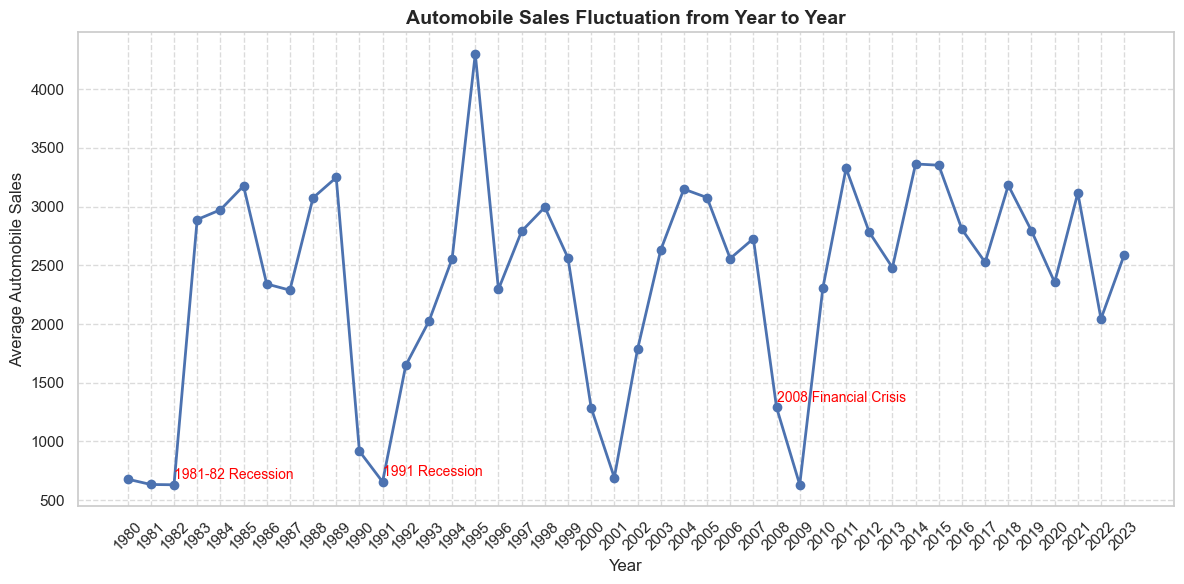

In [2]:
# Group by Year and sum Automobile Sales
df_line = df.groupby('Year')['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_line['Year'], df_line['Automobile_Sales'], marker='o', color='b', linewidth=2)
plt.title('Automobile Sales Fluctuation from Year to Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Automobile Sales', fontsize=12)
plt.xticks(df_line['Year'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate recession periods
recession_years = [1980, 1981, 1982, 1983, 1990, 1991, 1992, 2000, 2001, 2002, 2008, 2009, 2020]
plt.text(1982, df_line[df_line['Year']==1982]['Automobile_Sales'].values[0]+50, '1981-82 Recession', color='red', fontsize=10)
plt.text(1991, df_line[df_line['Year']==1991]['Automobile_Sales'].values[0]+50, '1991 Recession', color='red', fontsize=10)
plt.text(2008, df_line[df_line['Year']==2008]['Automobile_Sales'].values[0]+50, '2008 Financial Crisis', color='red', fontsize=10)

plt.tight_layout()
plt.show()


### TASK 1.2: Plot different lines for categories of vehicle type and analyze the trend to correlate the advertising expenditure with sales during non-recession periods

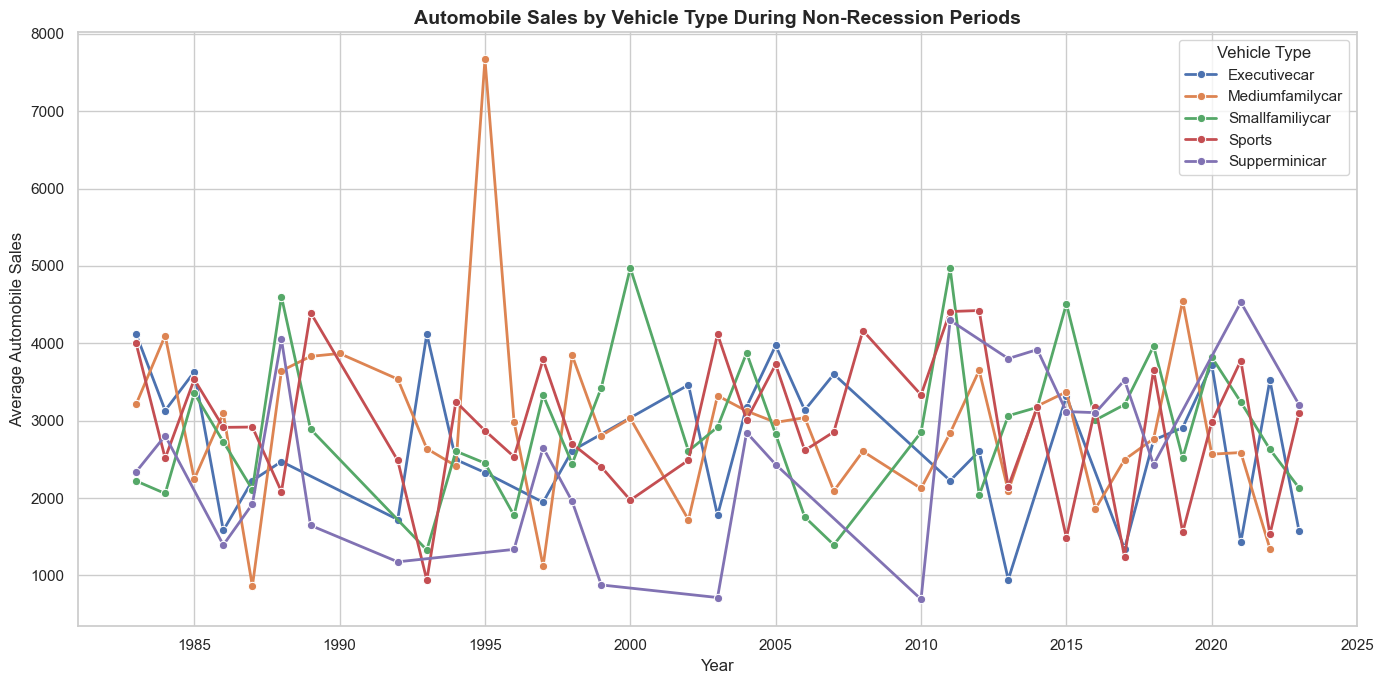

In [3]:
# Filter non-recession data
df_non_rec = df[df['Recession'] == 0]

# Group by Year and Vehicle_Type
df_vtype = df_non_rec.groupby(['Year', 'Vehicle_Type'])[['Automobile_Sales', 'Advertising_Expenditure']].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_vtype, x='Year', y='Automobile_Sales', hue='Vehicle_Type', marker='o', linewidth=2)
plt.title('Automobile Sales by Vehicle Type During Non-Recession Periods', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Automobile Sales', fontsize=12)
plt.legend(title='Vehicle Type', loc='upper right')
plt.tight_layout()
plt.show()


### TASK 1.3: Use the functionality of Seaborn Library to create a bar chart to compare the sales trend per vehicle type for a recession period with a non-recession period

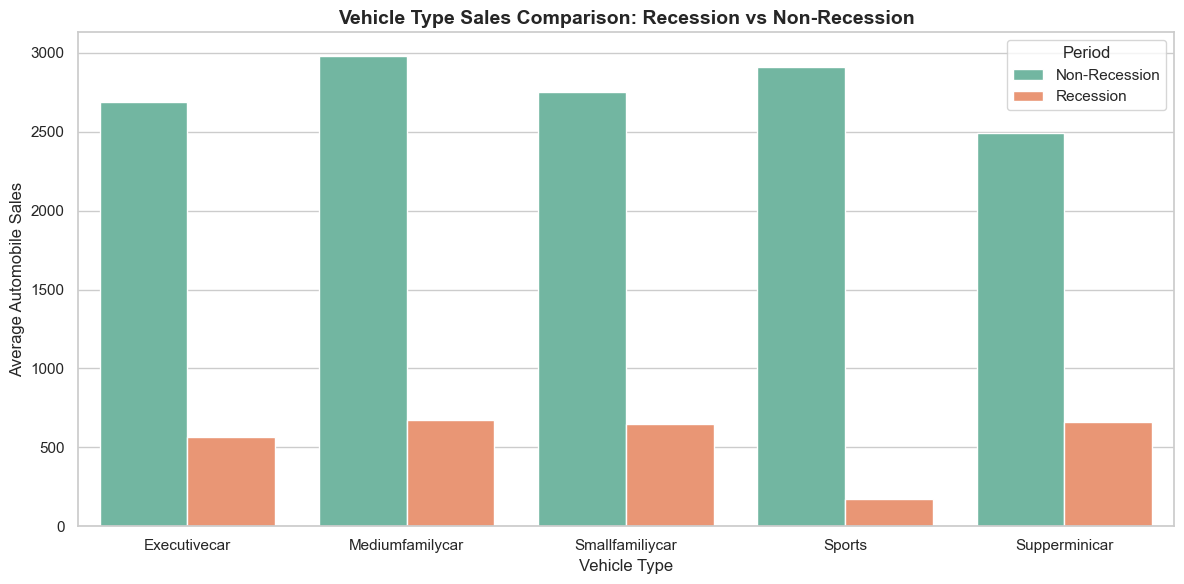

In [4]:
# Group by Recession status and Vehicle Type
df_rec_comp = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
df_rec_comp['Recession_Label'] = df_rec_comp['Recession'].replace({0: 'Non-Recession', 1: 'Recession'})

plt.figure(figsize=(12, 6))
sns.barplot(data=df_rec_comp, x='Vehicle_Type', y='Automobile_Sales', hue='Recession_Label', palette='Set2')
plt.title('Vehicle Type Sales Comparison: Recession vs Non-Recession', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Average Automobile Sales', fontsize=12)
plt.legend(title='Period')
plt.tight_layout()
plt.show()


### TASK 1.4: Use subplots for comparing the variations in GDP during recession and non-recession periods

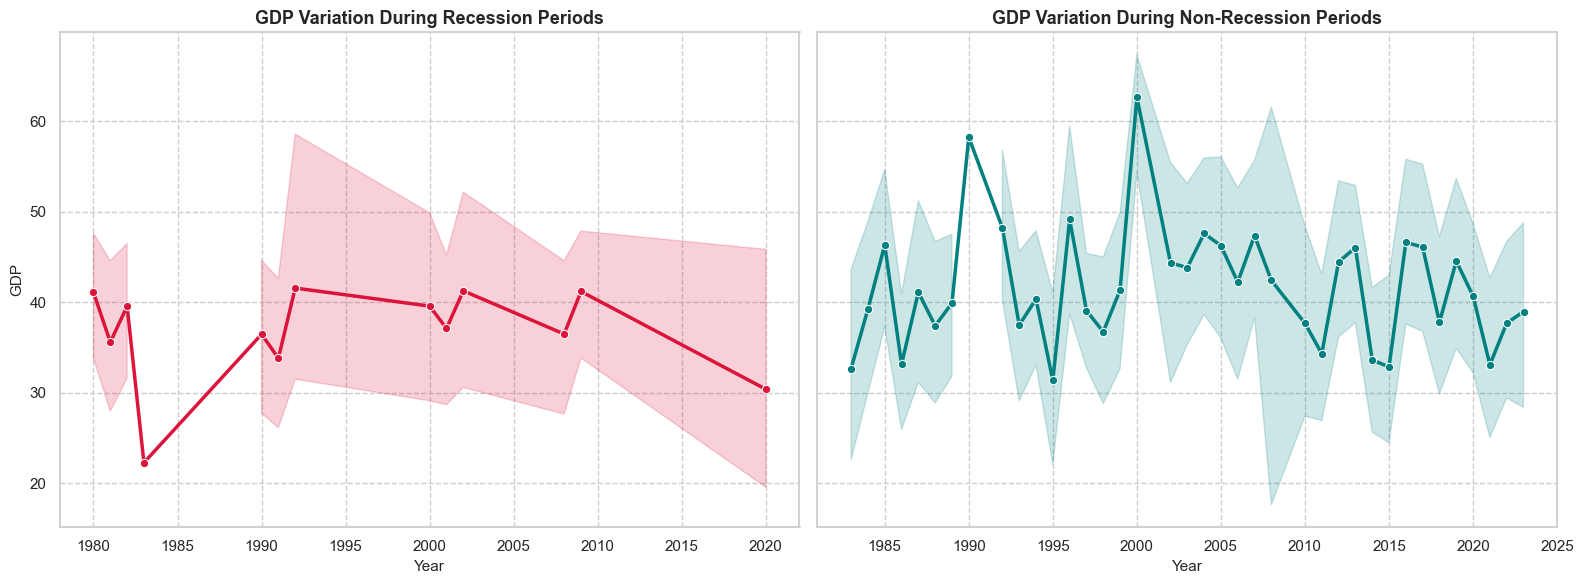

In [5]:
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Subplot 1: Recession GDP
sns.lineplot(ax=axes[0], data=rec_data, x='Year', y='GDP', marker='o', color='crimson', linewidth=2.5)
axes[0].set_title('GDP Variation During Recession Periods', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('GDP', fontsize=11)
axes[0].grid(True, linestyle='--')

# Subplot 2: Non-Recession GDP
sns.lineplot(ax=axes[1], data=non_rec_data, x='Year', y='GDP', marker='o', color='teal', linewidth=2.5)
axes[1].set_title('GDP Variation During Non-Recession Periods', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('GDP', fontsize=11)
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()


### TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales

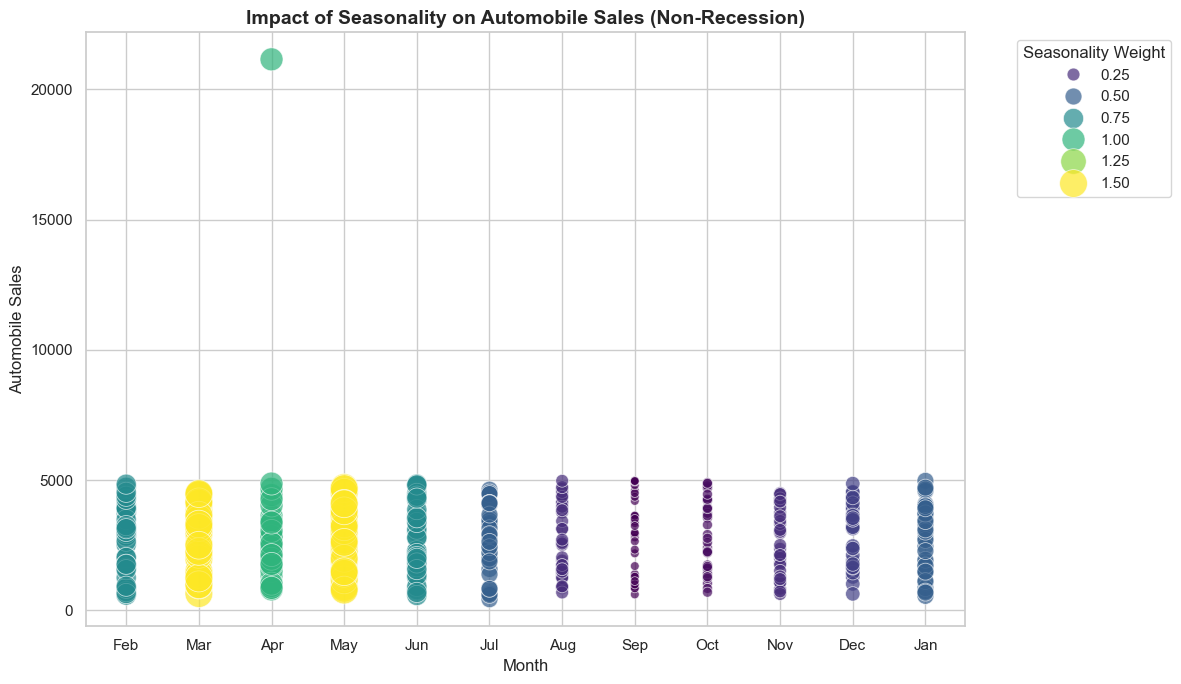

In [6]:
non_rec_data = df[df['Recession'] == 0]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=non_rec_data,
    x='Month',
    y='Automobile_Sales',
    size='Seasonality_Weight',
    hue='Seasonality_Weight',
    sizes=(40, 400),
    palette='viridis',
    alpha=0.7
)

plt.title('Impact of Seasonality on Automobile Sales (Non-Recession)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Automobile Sales', fontsize=12)
plt.legend(title='Seasonality Weight', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### TASK 1.6: Use the functionality of Seaborn to create a scatter plot to identify the correlation between average vehicle price relate to the sales volume during recessions

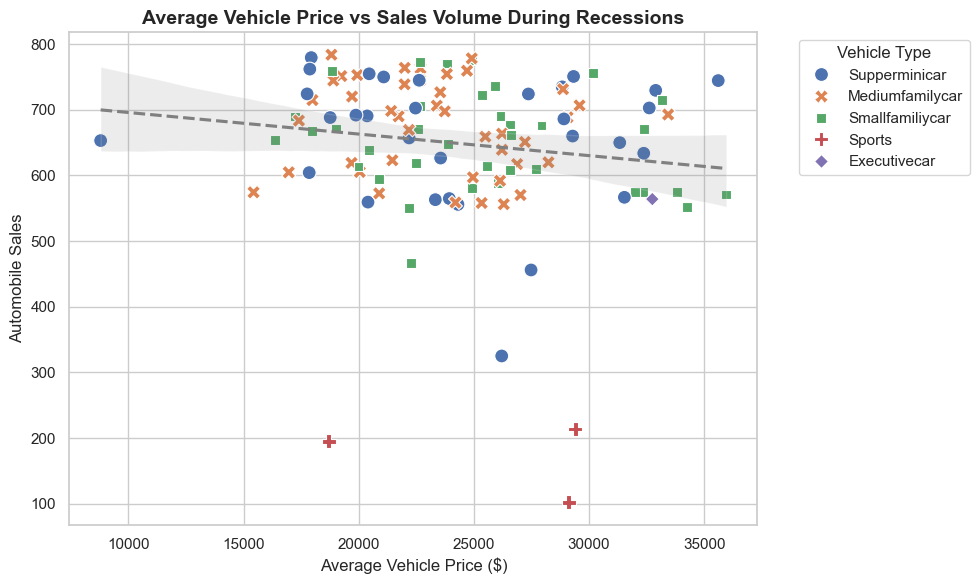

In [7]:
rec_data = df[df['Recession'] == 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rec_data, x='Price', y='Automobile_Sales', hue='Vehicle_Type', style='Vehicle_Type', s=100, palette='deep')
sns.regplot(data=rec_data, x='Price', y='Automobile_Sales', scatter=False, color='gray', line_kws={'linestyle':'--'})

plt.title('Average Vehicle Price vs Sales Volume During Recessions', fontsize=14, fontweight='bold')
plt.xlabel('Average Vehicle Price ($)', fontsize=12)
plt.ylabel('Automobile Sales', fontsize=12)
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### TASK 1.7: Create a Pie chart to display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods

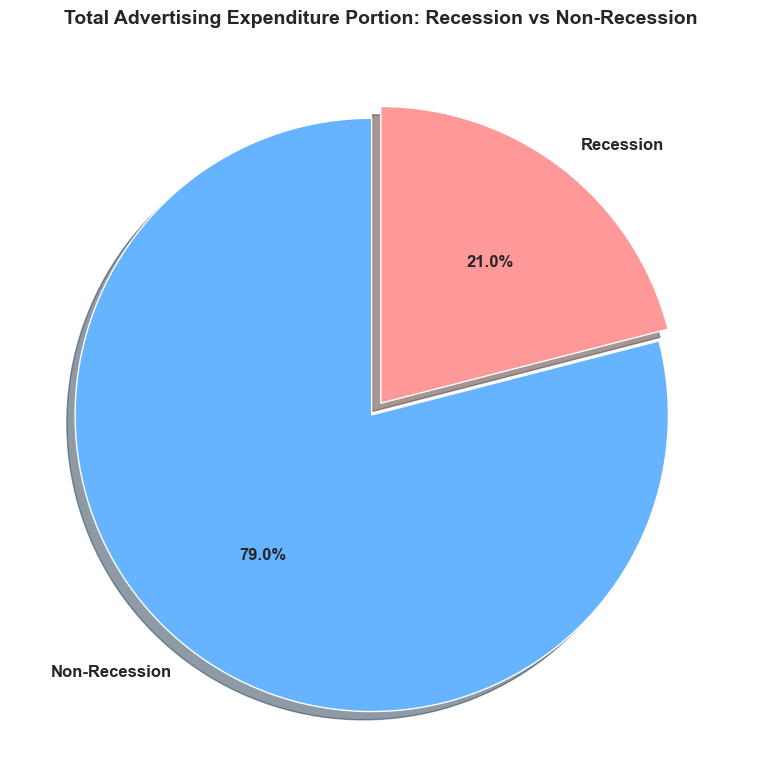

In [8]:
ad_data = df.groupby('Recession')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    ad_data, 
    labels=['Non-Recession', 'Recession'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#66b3ff', '#ff9999'], 
    explode=(0.05, 0), 
    shadow=True,
    textprops={'fontsize': 12, 'weight': 'bold'}
)
plt.title('Total Advertising Expenditure Portion: Recession vs Non-Recession', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### TASK 1.8: Develop a Pie chart to display the total Advertisement expenditure for each vehicle type during the recession period

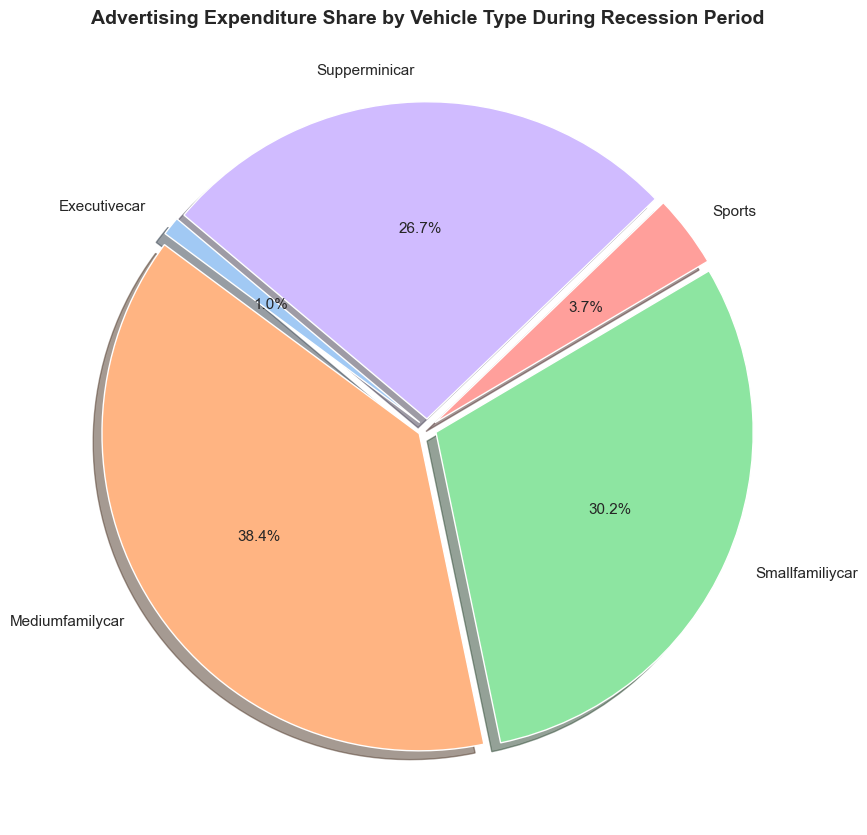

In [9]:
rec_data = df[df['Recession'] == 1]
vtype_ad = rec_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(9, 9))
plt.pie(
    vtype_ad, 
    labels=vtype_ad.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel', len(vtype_ad)),
    explode=[0.03]*len(vtype_ad),
    shadow=True,
    textprops={'fontsize': 11}
)
plt.title('Advertising Expenditure Share by Vehicle Type During Recession Period', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### TASK 1.9: Develop a lineplot to analyze the effect of the unemployment rate on vehicle type and sales during the Recession Period

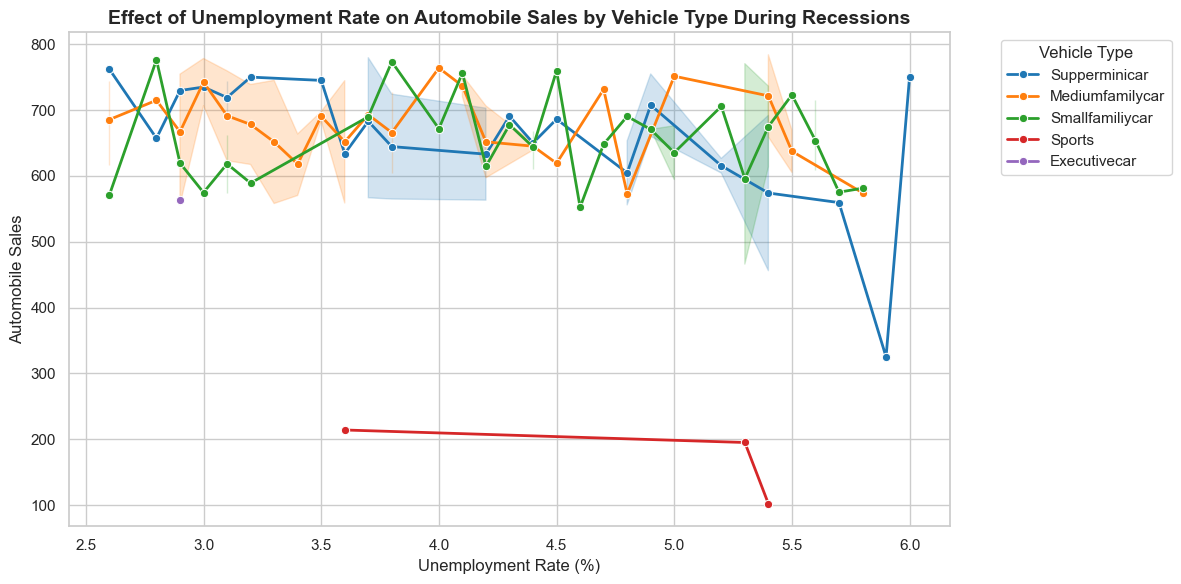

In [10]:
rec_data = df[df['Recession'] == 1]

plt.figure(figsize=(12, 6))
sns.lineplot(data=rec_data, x='unemployment_rate', y='Automobile_Sales', hue='Vehicle_Type', marker='o', palette='tab10', linewidth=2)
plt.title('Effect of Unemployment Rate on Automobile Sales by Vehicle Type During Recessions', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (%)', fontsize=12)
plt.ylabel('Automobile Sales', fontsize=12)
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
